In [ ]:
import os
import math
import numpy as np

import torch
from torchvision import transforms
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader
from datasets import load_dataset
from tqdm import tqdm

from GeospatialFM.datasets.ssl4eo.utils import get_ssl4eo_metadata
from GeospatialFM.data_process import pretrain_transform, multimodal_collate_fn
from GeospatialFM.models import SpatialSpectralLowRankViTConfig, SpatialSpectralMAEViT
from GeospatialFM.models.low_rank_attention import get_perception_field_mask
from GeospatialFM.models import PositionalChannelEmbedding
from GeospatialFM.datasets.ssl4eo import SSL4EODataset
from GeospatialFM.scripts.trainer import MAETrainer

from functools import partial
from accelerate import Accelerator
from transformers import TrainingArguments

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# import rasterio
import pandas as pd
import json

%load_ext autoreload
%autoreload 2

## Perception Field Mask

In [ ]:
patch_size = 16
num_patches = 64
perception_field_mask = get_perception_field_mask(num_patches, patch_size, 10, attention_radius=640, cls_token=False)
perception_field_mask.shape
plt.imshow(perception_field_mask.numpy())
# plt.axis('off')
plt.xticks([-0.5, num_patches-0.5], labels=[0, num_patches])
plt.yticks([-0.5, num_patches-0.5], labels=[0, num_patches])
# plt.title("Attention Mask Example: 196x196", fontsize=10, fontweight='bold')
plt.show()
# plt.savefig("perception_field_attention_mask.pdf", bbox_inches='tight', pad_inches=0.)

In [ ]:
one_perception = perception_field_mask[0].reshape(int(math.sqrt(perception_field_mask.shape[1])), int(math.sqrt(perception_field_mask.shape[1]))).numpy()
idx = torch.rand(num_patches)
keep_idx = torch.argsort(idx)[:int(num_patches*0.25)]
random_mask = torch.zeros(num_patches)
random_mask[keep_idx] = 1
random_mask = random_mask.reshape(int(math.sqrt(num_patches)), int(math.sqrt(num_patches)))
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(random_mask.numpy())
ax[0].set_title("Random MAE Mask")
ax[1].imshow(one_perception, vmin=0, vmax=1)
ax[1].set_title("One Perception Field Mask")
ax[2].imshow(random_mask.numpy() * one_perception)
ax[2].set_title("Actual MAE Mask")
plt.show()
# print(perception_field_mask[0].reshape(int(math.sqrt(perception_field_mask.shape[1])), int(math.sqrt(perception_field_mask.shape[1]))).numpy().sum())

In [ ]:
# apply random mask to perception field mask
random_mask_idx = random_mask.reshape(-1).nonzero().squeeze()
perception_field_mask_masked = perception_field_mask[random_mask_idx][:, random_mask_idx]
plt.imshow(perception_field_mask_masked.numpy())

## PositionalChannel Embedding

In [ ]:
pos_chan_embed = PositionalChannelEmbedding(embed_dim=768)
tokens = torch.randn(1, 5, 64, 768)
# channel_ids = torch.arange(5).unsqueeze(0) * 1000
channel_ids = torch.tensor([492.4, 559.8, 664.6, 1613.7, 2202.4]).unsqueeze(0)
pos_embed = pos_chan_embed(tokens, 10, channel_ids, cls_token=False).squeeze(0)
print(pos_embed.shape)

In [ ]:
# print the embedding of the first channel
plt.figure(figsize=(10, 10))
plt.imshow(torch.cat([pos_embed[i] for i in range(5)], dim=0), cmap="inferno")
# add tick label to y axis
plt.yticks(np.arange(11)*32-0.5, labels=[f"$\lambda$ = {float(channel_ids[0, i//2]):.1f} $\mu m$" if i % 2 == 1 else "" for i in range(11)], fontsize=12, fontweight='bold')
# 
plt.xticks(np.array([0, 96, 192, 288, 384, 480, 576, 672, 768])-0.5, labels=[0, 96, 192, 288, 384, 480, 576, 672, 768], fontsize=12)
# plt.axis('off')
plt.xlabel("Embedding Dimension", fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig("positional_channel_embedding.pdf", bbox_inches='tight', pad_inches=0)

## SSL4EO

In [10]:
metadata = get_ssl4eo_metadata()
optical_mean, optical_std = metadata["s2c"]["mean"], metadata["s2c"]["std"]
radar_mean, radar_std = metadata["s1"]["mean"], metadata["s1"]["std"]

In [ ]:
dataset = dict(train=SSL4EODataset(root="./data/geospatial/SSL4EO"))
transform = partial(pretrain_transform, optical_mean=optical_mean, optical_std=optical_std, radar_mean=radar_mean, radar_std=radar_std)

In [ ]:
def norm_img(img):
    return (img - img.min()) / (img.max() - img.min())

# data_idx = np.random.randint(0, len(dataset['train']))
# data_idx = 117967
data_idx = 0
# print(data_idx)
sample = transform(dataset['train'][data_idx])
sample_optical_image = torch.tensor(sample['optical']).numpy()
sample_radar_image = torch.tensor(sample['radar']).numpy()
sample_image = np.concatenate([sample_optical_image, sample_radar_image], axis=0)
bands = metadata["s2c"]["bands"] + metadata["s1"]["bands"]
rgb_image = sample_optical_image[[3, 2, 1]].transpose(1, 2, 0)
rgb_image = norm_img(rgb_image)

# visualize a data sample
# mpl.rcParams['axes.titlesize'] = 28
# mpl.rcParams['axes.labelsize'] = 24
# mpl.rcParams['xtick.labelsize'] = 18
# mpl.rcParams['ytick.labelsize'] = 18

# Number of images excluding the RGB image
num_images = sample_image.shape[0]
# pick the 75 quantile location of each channel
random_locs = []
target_labels = []

for i in [0, 0.25, 0.5, 0.75, 1]:
    quantile = int(sample_image[1].size*i) if i != 1 else -1
    loc = np.unravel_index(np.argsort(sample_image[1].flatten())[quantile], sample_image[1].shape)
    random_locs.append(loc)
    target_labels.append(f"{i*100}%")

# Create a figure
fig = plt.figure(figsize=(32, 9))  # Adjust the figure size as needed

# Create a GridSpec with 3 rows and 8 columns
gs = GridSpec(3, 11, figure=fig)

ax_img = fig.add_subplot(gs[:, :3])
ax_img.imshow(rgb_image)
ax_img.axis('off')
ax_img.set_title('RGB Image')
for loc in random_locs:
    ax_img.plot(loc[1], loc[0], 'x', markersize=10, markeredgewidth=4)

# The rest of the images (adjust the range according to your number of images)
for i in range(num_images):
    # Calculate the position for the current image
    row = i // 5
    col = i % 5 
    ax = fig.add_subplot(gs[row, col+3])
    ax.imshow(sample_image[i])  # Replace with each individual image array
    # plot cross at random locations
    for loc in random_locs:
        ax.plot(loc[1], loc[0], 'x', markersize=10, markeredgewidth=4)
    # bold the title
    ax.set_title(f"{bands[i]}")  # Replace with the title for each image
    ax.axis('off')

ax_curve = fig.add_subplot(gs[:, -3:])
for loc, label in zip(random_locs, target_labels):
    ax_curve.plot(np.arange(len(bands)), sample_image[:, loc[0], loc[1]], linewidth=3, marker='o', markersize=6, label=label)
# ax_curve.legend(loc='upper right', fontsize=18)
# ax_curve.set_xlabel('Bands')
ax_curve.set_ylabel('Normalized Reflectance')
ax_curve.set_title('Spectral Signature at Marked Locations')
ax_curve.set_yticks([])
# set the band names as xticks
ax_curve.set_xticks(np.arange(len(bands)))
ax_curve.set_xticklabels(bands, rotation=90)

plt.tight_layout()
plt.show()
# save as pdf
# plt.savefig('spectral_signature.pdf', bbox_inches='tight', pad_inches=0.1)

In [ ]:
# os.makedirs("patches/masked")
# idx = torch.rand(16)
# keep_idx = torch.argsort(idx)[:int(16*0.5)]
# random_mask = torch.zeros(16)
# random_mask[keep_idx] = 1

# print(random_mask)
# channel_idx = torch.rand(num_images)
# keep_channel_idx = torch.argsort(channel_idx)[:int(num_images*0.5)]
# randon_channel_mask = torch.zeros(num_images) 
# randon_channel_mask[keep_channel_idx] = 1

# cut the sample image into 3x3 patches
patch_size = 264//3
channel_indices = [1, 2, 3, 4, 13, 14]

fig, ax = plt.subplots(7, 7, figsize=(10, 10))
for i in range(7):
    for j in range(7):
        if i == 0 and j == 0:
            # fill in yellowish red pure color
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.8, cmap='Oranges', vmin=0, vmax=1)
        elif i == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.2, cmap='YlOrRd', vmin=0, vmax=1)
        elif j == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.3, cmap='Greens', vmin=0, vmax=1)
        else:
            plot_i = i-1
            plot_j = j-1
            ax[j, i].imshow(sample_image[channel_indices[plot_i], plot_j//3*patch_size:(plot_j//3+1)*patch_size, plot_j%3*patch_size:(plot_j%3+1)*patch_size])
        ax[j, i].axis('off')
plt.tight_layout()
# plt.show()
plt.savefig("sample_patches.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
patch_size = 264//3
channel_indices = [1, 2, 3, 4, 13, 14]
masked_channel_indices = [1, 3, 4]
masked_positions = [0, 1, 3, 5]
print(masked_channel_indices, masked_positions)

fig, ax = plt.subplots(7, 7, figsize=(10, 10))
for i in range(7):
    for j in range(7):
        if i == 0 and j == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.8, cmap='Oranges', vmin=0, vmax=1)
        elif i == 0:
            if j-1 in masked_positions:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.4, cmap='Greys', vmin=0, vmax=1)
            else:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.2, cmap='YlOrRd', vmin=0, vmax=1)
        elif j == 0:
            if i-1 in masked_channel_indices:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.4, cmap='Greys', vmin=0, vmax=1)
            else:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.3, cmap='Greens', vmin=0, vmax=1)
        else:
            plot_i = i-1
            plot_j = j-1
            if plot_i in masked_channel_indices or plot_j in masked_positions:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.4, cmap='Greys', vmin=0, vmax=1)
            else:
                ax[j, i].imshow(sample_image[channel_indices[plot_i], plot_j//3*patch_size:(plot_j//3+1)*patch_size, plot_j%3*patch_size:(plot_j%3+1)*patch_size])
        ax[j, i].axis('off')
plt.tight_layout()
# plt.show()
plt.savefig("masked_patches.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
patch_size = 264//3
channel_indices = [1, 2, 3, 4, 13, 14]
masked_channel_indices = [1, 3, 4]
unmasked_channel_indices = [0, 2, 5]
masked_positions = [0, 1, 3, 5]
unmasked_positions = [2, 4]
print(masked_channel_indices, masked_positions)

fig, ax = plt.subplots(7, 7, figsize=(10, 10))
for i in range(7):
    for j in range(7):
        if i == 0 and j == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.8, cmap='Oranges', vmin=0, vmax=1)
        elif i == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.2, cmap='YlOrRd', vmin=0, vmax=1)
        elif j == 0:
            ax[j, i].imshow(np.ones((patch_size, patch_size))*0.3, cmap='Greens', vmin=0, vmax=1)
        else:
            try:
                plot_i = unmasked_channel_indices[i-1]
                plot_j = unmasked_positions[j-1]
                ax[j, i].imshow(sample_image[channel_indices[plot_i], plot_j//3*patch_size:(plot_j//3+1)*patch_size, plot_j%3*patch_size:(plot_j%3+1)*patch_size])
            except:
                ax[j, i].imshow(np.ones((patch_size, patch_size))*0.5, cmap='Greys', vmin=0, vmax=1)
        ax[j, i].axis('off')
plt.tight_layout()
# plt.show()
plt.savefig("masked_patches_2.pdf", bbox_inches='tight', pad_inches=0)


In [ ]:
def get_mask_and_visualization(image, image_size, patch_size=16, attention_radius=640, median_mask=0.55, alpha=0.3):
    num_patches = (image_size // patch_size)**2
    perception_field_mask = get_perception_field_mask(num_patches, patch_size, 10, attention_radius=attention_radius, cls_token=False)
    vis_perception_mask = perception_field_mask[int(num_patches*median_mask)].reshape(int(math.sqrt(perception_field_mask.shape[1])), int(math.sqrt(perception_field_mask.shape[1]))).numpy()
    vis_perception_mask = TF.resize(torch.tensor(vis_perception_mask).unsqueeze(0), size=(image_size, image_size), interpolation=TF.InterpolationMode.NEAREST).squeeze(0)
    
    image = image.copy()
    image = TF.center_crop(torch.tensor(image).permute(2, 0, 1), output_size=(image_size, image_size)).permute(1, 2, 0).numpy()
    applied_mask = (1-vis_perception_mask.unsqueeze(-1).numpy()) * (1-alpha) + (1-vis_perception_mask.unsqueeze(-1).numpy()) * image * alpha + (vis_perception_mask.unsqueeze(-1)).numpy()*image
    target_patch_idx = int(median_mask*num_patches)
    target_i = target_patch_idx // int(num_patches**0.5)
    target_j = target_patch_idx % int(num_patches**0.5)
    return perception_field_mask, applied_mask, target_i, target_j

vis_perception_mask_256, applied_mask_256, target_i_256, target_j_256 = get_mask_and_visualization(rgb_image, 256)
vis_perception_mask_224, applied_mask_224, target_i_224, target_j_224 = get_mask_and_visualization(rgb_image, 224)
vis_perception_mask_192, applied_mask_192, target_i_192, target_j_192 = get_mask_and_visualization(rgb_image, 192)
vis_perception_mask_128, applied_mask_128, target_i_128, target_j_128 = get_mask_and_visualization(rgb_image, 128)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))  # Adjusted to 2x4 layout

ax[0, 0].imshow(applied_mask_256)
ax[0, 0].add_patch(plt.Rectangle((target_j_256*16, target_i_256*16), 16, 16, edgecolor='red', facecolor='none'))
ax[0, 0].set_title("Image Size: 256x256", fontsize=26, fontweight='bold')
ax[0, 0].axis('off')


ax[0, 1].imshow(applied_mask_224)
ax[0, 1].set_title("Image Size: 224x224", fontsize=26, fontweight='bold')
ax[0, 1].add_patch(plt.Rectangle((target_j_224*16, target_i_224*16), 16, 16, edgecolor='red', facecolor='none'))
ax[0, 1].axis('off')

ax[1, 0].imshow(applied_mask_192)
ax[1, 0].set_title("Image Size: 192x192", fontsize=26, fontweight='bold')
ax[1, 0].add_patch(plt.Rectangle((target_j_192*16, target_i_192*16), 16, 16, edgecolor='red', facecolor='none'))
ax[1, 0].axis('off')

ax[1, 1].imshow(applied_mask_128)
ax[1, 1].set_title("Image Size: 128x128", fontsize=28, fontweight='bold')
ax[1, 1].add_patch(plt.Rectangle((target_j_128*16, target_i_128*16), 16, 16, edgecolor='red', facecolor='none'))
ax[1, 1].axis('off')
plt.tight_layout()
plt.show()
# title
# plt.suptitle("Perception Field Attention Mask", fontsize=18, fontweight='bold')
# plt.savefig("perception_field_mask.pdf", bbox_inches='tight', pad_inches=0.)

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))  # Adjusted to 2x4 layout

ax[0, 0].imshow(vis_perception_mask_256)
ax[0, 0].set_title("Patch Number: 256", fontsize=26, fontweight='bold')
ax[0, 0].axis('off')

ax[0, 1].imshow(applied_mask_256)
ax[0, 1].add_patch(plt.Rectangle((target_j_256*16, target_i_256*16), 16, 16, edgecolor='red', facecolor='none'))
ax[0, 1].set_title("Image Size: 256x256", fontsize=26, fontweight='bold')
ax[0, 1].axis('off')

ax[0, 2].imshow(vis_perception_mask_224)
ax[0, 2].set_title("Patch Number: 196", fontsize=26, fontweight='bold')
ax[0, 2].axis('off')

ax[0, 3].imshow(applied_mask_224)
ax[0, 3].set_title("Image Size: 224x224", fontsize=26, fontweight='bold')
ax[0, 3].add_patch(plt.Rectangle((target_j_224*16, target_i_224*16), 16, 16, edgecolor='red', facecolor='none'))
ax[0, 3].axis('off')

ax[1, 0].imshow(vis_perception_mask_192)
ax[1, 0].set_title("Patch Number: 144", fontsize=26, fontweight='bold')
ax[1, 0].axis('off')

ax[1, 1].imshow(applied_mask_192)
ax[1, 1].set_title("Image Size: 192x192", fontsize=26, fontweight='bold')
ax[1, 1].add_patch(plt.Rectangle((target_j_192*16, target_i_192*16), 16, 16, edgecolor='red', facecolor='none'))
ax[1, 1].axis('off')

ax[1, 2].imshow(vis_perception_mask_128)
ax[1, 2].set_title("Patch Number: 64", fontsize=26, fontweight='bold')
ax[1, 2].axis('off')

ax[1, 3].imshow(applied_mask_128)
ax[1, 3].set_title("Image Size: 128x128", fontsize=26, fontweight='bold')
ax[1, 3].add_patch(plt.Rectangle((target_j_128*16, target_i_128*16), 16, 16, edgecolor='red', facecolor='none'))
ax[1, 3].axis('off')
plt.tight_layout()
plt.savefig("perception_field_mask_visualization.pdf", bbox_inches='tight', pad_inches=0)

In [ ]:
# plt.imshow(((1-vis_perception_mask_256.unsqueeze(-1).numpy()) * img_256 * 0.3))
plt.axis('off')
plt.show()

## Dataloader with Image Size Changing

In [11]:
batch_size = 8

collate_fn = partial(multimodal_collate_fn, transform=pretrain_transform, normalization=apply_transform)

train_loader = DataLoader(
    dataset['train'], 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=4, 
    collate_fn=collate_fn
)

# for n, batch in enumerate(train_loader):
#     print(batch['optical'].shape)
#     if n == 4:
#         break

## Model

In [ ]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define configuration
config = SpatialSpectralLowRankViTConfig(
    patch_size=16,
    embed_dim=768,
    depth=12,
    num_heads=12,
    decoder_embed_dim=512,
    decoder_depth=8,
    decoder_num_heads=16,
    use_perception_field_mask=True,
    attention_radius=640,
    norm_pix_loss=False,
)

# Initialize model
model = SpatialSpectralMAEViT(config)

model

In [ ]:
# find the number of parameters
num_params = sum(p.numel() for p in model.encoder.parameters())
print(f"Number of parameters: {num_params}")

## Training Code

In [8]:
# Set model to training mode
model.to('cuda:0', dtype=torch.bfloat16)
model.train()

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# # load checkpoint
# model.load_state_dict(torch.load("/home/haozhesi/Dropbox/GeospatialFM/results/models/LRSSVIT/checkpoint-1000/pytorch_model.bin"))

In [ ]:
for batch in tqdm(train_loader):
    optical = batch['optical'].to('cuda:0', dtype=torch.bfloat16)
    radar = batch['radar'].to('cuda:0', dtype=torch.bfloat16)
    optical_channel_wv = batch['optical_channel_wv']
    radar_channel_wv = batch['radar_channel_wv']
    spatial_resolution = batch['spatial_resolution']
    # Run forward pass
    output = model(
        optical=optical,
        radar=radar,
        optical_channel_wv=optical_channel_wv,
        radar_channel_wv=radar_channel_wv,
        mask_ratio=0.75,
        channel_mask_ratio=0.5,
        spatial_resolution=spatial_resolution,
    )
    break

# Check output
expected_keys = [
    'target',
    'optical_channel_mask', 'optical_recon', 'optical_pos_mask',
    'radar_channel_mask', 'radar_recon', 'radar_pos_mask',
    'multi_channel_mask', 'multi_recon', 'multi_pos_mask'
]

for key in expected_keys:
    assert key in output, f"Missing key in output: {key}"
    assert isinstance(output[key], torch.Tensor), f"Output {key} is not a tensor"

In [ ]:
# manually compute the loss
loss = {}
total_loss = 0
target = output['target']
for modal in ['optical', 'radar', 'multi']:
    if f'{modal}_recon' in output:
        recon = output[f'{modal}_recon']
        channel_mask = output[f'{modal}_channel_mask']
        pos_mask = output[f'{modal}_pos_mask']
        # positional MSE
        pos_loss = (torch.mean((recon - target) ** 2, dim=[1, 3]) * pos_mask).sum() / pos_mask.sum()
        # channel MSE
        channel_loss = (torch.mean((recon - target) ** 2, dim=[2, 3]) * channel_mask).sum() / channel_mask.sum()
        loss[f"{modal}_pos_loss"] = pos_loss
        loss[f"{modal}_channel_loss"] = channel_loss
        loss[f"{modal}_loss"] = pos_loss + channel_loss
        total_loss += loss[f"{modal}_loss"]
loss['total_loss'] = total_loss
print(loss)

In [11]:
# step
optimizer.zero_grad()
total_loss.backward()
optimizer.step()

In [1]:
import numpy as np

lam = np.array([
418.24, 423.874, 429.294, 434.528, 439.603, 444.549, 449.391, 454.159, 458.884, 463.584, 468.265, 472.934, 477.599, 482.265, 486.941, 491.633, 496.349, 501.094, 505.87, 510.678, 515.519, 520.397, 525.313, 530.268, 535.265, 540.305, 545.391, 550.525, 555.71, 560.947, 566.239, 571.587, 576.995, 582.464, 587.997, 593.596, 599.267, 605.011, 610.833, 616.737, 622.732, 628.797, 634.919, 641.1, 647.341, 653.643, 660.007, 666.435, 672.927, 679.485, 686.11, 692.804, 699.567, 706.401, 713.307, 720.282, 727.324, 734.431, 741.601, 748.833, 756.124, 763.472, 770.876, 778.333, 785.843, 793.402, 801.01, 808.665, 816.367, 824.112, 831.901, 839.731, 847.601, 855.509, 863.455, 871.433, 879.442, 887.478, 895.537, 902.257, 903.617, 911.715, 911.872, 919.827, 921.624, 927.951, 931.512, 936.082, 941.53, 944.217, 951.677, 952.355, 960.495, 961.948, 968.638, 972.341, 976.783, 982.851, 984.932, 993.083, 993.475, 1004.21, 1015.05, 1026.0, 1037.05, 1048.19, 1059.42, 1070.74, 1082.14, 1093.62, 1105.17, 1116.79, 1128.47, 1140.2, 1151.98, 1163.81, 1175.67, 1187.56, 1199.48, 1211.42, 1223.37, 1235.34, 1247.31, 1259.3, 1271.29, 1283.29, 1530.64, 1542.02, 1553.36, 1564.65, 1653.33, 1664.2, 1675.03, 1685.8, 1696.53, 1707.2, 1717.83, 1728.4, 1738.93, 1749.4, 1759.83, 1939.44, 1948.98, 1958.49, 1967.95, 1977.37, 1986.74, 1996.07, 2005.36, 2014.61, 2023.82, 2032.99, 2042.11, 2051.19, 2060.24, 2069.24, 2078.21, 2087.13, 2096.01, 2104.86, 2113.67, 2122.44, 2131.17, 2139.87, 2148.52, 2157.15, 2165.73, 2174.28, 2182.79, 2191.27, 2199.71, 2208.12, 2216.5, 2224.84, 2233.14, 2241.42, 2249.66, 2257.86, 2266.04, 2274.18, 2282.29, 2290.37, 2298.42, 2306.44, 2314.42, 2322.37, 2330.29, 2338.19, 2346.05, 2353.88, 2361.68, 2369.45, 2377.19, 2384.9, 2392.58, 2400.23, 2407.85, 2415.45, 2423.01, 2430.55, 2438.05, 2445.53
])
assert len(lam) == 202, len(lam)

IDX_B = [0,1,3,4,5,6,8,9,10,11,13,14,15,16,18,19,20,22,23,24,25,27,28,29,30,32,33,34,35,37,38,39,41,42,43,44,46,47,48,49,51,52,53,54,56,57,58,59,61,62,63,65,66,67,68,70,71,72,73,75,76,77,78,80,81,82,84,85,86,87,89,90,91,92,94,95,96,97,99,100,101,104,106,109,111,114,116,119,122,124,127,129,132,134,137,139,142,145,147,150,152,155,157,160,163,165,168,170,173,175,178,180,183,186,188,191,193,196,198,201]
IDX_A = [0,3,5,8,10,13,15,18,21,23,26,28,31,33,36,38,41,44,46,49,51,54,56,59,62,64,67,69,72,74,77,79,82,85,87,90,92,95,97,100,101,102,104,105,106,107,109,110,111,112,114,115,116,117,119,120,121,123,124,125,126,128,129,130,131,133,134,135,136,138,139,140,142,143,144,145,147,148,149,150,152,153,154,155,157,158,159,160,162,163,164,166,167,168,169,171,172,173,174,176,177,178,179,181,182,183,185,186,187,188,190,191,192,193,195,196,197,198,200,201]

train = sorted(IDX_B)                       # VNIR+ = training
sw    = sorted(IDX_A)                        # SWIR+
c82   = sorted(set(range(202)) - set(IDX_B)) # complement of VNIR+
c202  = list(range(202))                     # full

print("sizes: train(VNIR+)=%d  SWIR+=%d  C82=%d  C202=%d" % (len(train), len(sw), len(c82), len(c202)))
print("C82 VNIR/SWIR split:", sum(lam[i]<1000 for i in c82), sum(lam[i]>=1000 for i in c82))

# EnMAP FWHM: no per-band FWHM given, so approximate with local sampling interval
# as a conservative proxy (FWHM ~ sampling in a pushbroom HSI). Report ratio to this.
def local_spacing(lam_all):
    d = np.diff(np.sort(lam_all))
    s = np.empty(len(lam_all))
    order = np.argsort(lam_all)
    ds = np.concatenate([[d[0]], (d[:-1]+d[1:])/2, [d[-1]]])
    s[order] = ds
    return s
spacing = local_spacing(lam)

lam_train = lam[train]

def stats(eval_idx, label):
    rows = []
    for region, lo, hi in [("VNIR", 0, 1000), ("SWIR", 1000, 1e9)]:
        idx = [i for i in eval_idx if lo <= lam[i] < hi]
        if not idx:
            continue
        d = np.array([np.min(np.abs(lam[i]-lam_train)) for i in idx])
        exact = int((d==0).sum())
        nz = d[d>0]
        sp = np.array([spacing[i] for i in idx])[d>0] if len(nz) else np.array([])
        rows.append((label, region, len(idx), exact,
                     nz.min() if len(nz) else 0.0,
                     np.median(nz) if len(nz) else 0.0,
                     nz.max() if len(nz) else 0.0,
                     np.median(nz/sp) if len(nz) else 0.0))
    return rows

allrows = []
for idx, label in [(sw,"C120_SW+"), (c82,"C82"), (c202,"C202")]:
    allrows += stats(idx, label)

hdr = ("Config","Region","#bands","#exact","dmin(nm)","dmed(nm)","dmax(nm)","med d/spacing")
print("\n" + " | ".join(f"{h:>13}" for h in hdr))
for r in allrows:
    print(" | ".join(f"{v:>13}" if isinstance(v,(int,str)) else f"{v:>13.2f}" for v in r))

# coverage gaps: largest interval in each region with no training band
for region, lo, hi in [("VNIR",0,1000),("SWIR",1000,1e9)]:
    t = sorted(l for l in lam_train if lo<=l<hi)
    gaps = np.diff(t)
    print(f"\n{region}: train bands={len(t)}, max gap between adjacent train bands={gaps.max():.1f} nm at ~{t[gaps.argmax()]:.0f} nm")

sizes: train(VNIR+)=120  SWIR+=120  C82=82  C202=202
C82 VNIR/SWIR split: 21 61

       Config |        Region |        #bands |        #exact |      dmin(nm) |      dmed(nm) |      dmax(nm) | med d/spacing
     C120_SW+ |          VNIR |            40 |            32 |          1.36 |          5.51 |          7.95 |          1.00
     C120_SW+ |          SWIR |            80 |            32 |          7.48 |          9.15 |         21.70 |          1.00
          C82 |          VNIR |            21 |             0 |          1.36 |          5.23 |          7.95 |          1.00
          C82 |          SWIR |            61 |             0 |          7.48 |          9.12 |         21.70 |          1.00
         C202 |          VNIR |           101 |            80 |          1.36 |          5.23 |          7.95 |          1.00
         C202 |          SWIR |           101 |            40 |          7.48 |          9.12 |         21.70 |          1.00

VNIR: train bands=80, max gap betwee

saved band_positions.png and band_positions.pdf


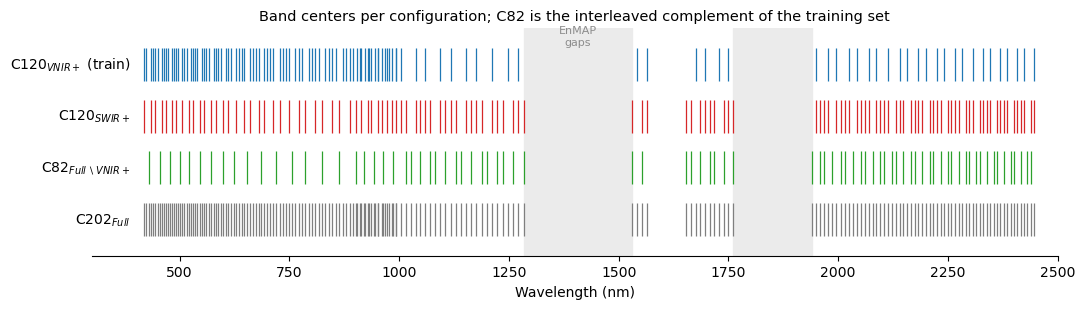

In [3]:
"""
Standalone band-position rug plot for the wavelength-overlap figure.
Config mapping (per your spec):
  IDX_B = C120_VNIR+  (training)
  IDX_A = C120_SWIR+
  complement of IDX_B = C82
  full 202 = C202
"""
import numpy as np
import matplotlib.pyplot as plt

# --- EnMAP band centers (nm), 202 bands ---
lam = np.array([
418.24,423.874,429.294,434.528,439.603,444.549,449.391,454.159,458.884,463.584,
468.265,472.934,477.599,482.265,486.941,491.633,496.349,501.094,505.87,510.678,
515.519,520.397,525.313,530.268,535.265,540.305,545.391,550.525,555.71,560.947,
566.239,571.587,576.995,582.464,587.997,593.596,599.267,605.011,610.833,616.737,
622.732,628.797,634.919,641.1,647.341,653.643,660.007,666.435,672.927,679.485,
686.11,692.804,699.567,706.401,713.307,720.282,727.324,734.431,741.601,748.833,
756.124,763.472,770.876,778.333,785.843,793.402,801.01,808.665,816.367,824.112,
831.901,839.731,847.601,855.509,863.455,871.433,879.442,887.478,895.537,902.257,
903.617,911.715,911.872,919.827,921.624,927.951,931.512,936.082,941.53,944.217,
951.677,952.355,960.495,961.948,968.638,972.341,976.783,982.851,984.932,993.083,
993.475,1004.21,1015.05,1026.0,1037.05,1048.19,1059.42,1070.74,1082.14,1093.62,
1105.17,1116.79,1128.47,1140.2,1151.98,1163.81,1175.67,1187.56,1199.48,1211.42,
1223.37,1235.34,1247.31,1259.3,1271.29,1283.29,1530.64,1542.02,1553.36,1564.65,
1653.33,1664.2,1675.03,1685.8,1696.53,1707.2,1717.83,1728.4,1738.93,1749.4,
1759.83,1939.44,1948.98,1958.49,1967.95,1977.37,1986.74,1996.07,2005.36,2014.61,
2023.82,2032.99,2042.11,2051.19,2060.24,2069.24,2078.21,2087.13,2096.01,2104.86,
2113.67,2122.44,2131.17,2139.87,2148.52,2157.15,2165.73,2174.28,2182.79,2191.27,
2199.71,2208.12,2216.5,2224.84,2233.14,2241.42,2249.66,2257.86,2266.04,2274.18,
2282.29,2290.37,2298.42,2306.44,2314.42,2322.37,2330.29,2338.19,2346.05,2353.88,
2361.68,2369.45,2377.19,2384.9,2392.58,2400.23,2407.85,2415.45,2423.01,2430.55,
2438.05,2445.53])
assert len(lam) == 202

IDX_B = [0,1,3,4,5,6,8,9,10,11,13,14,15,16,18,19,20,22,23,24,25,27,28,29,30,32,33,34,35,37,
         38,39,41,42,43,44,46,47,48,49,51,52,53,54,56,57,58,59,61,62,63,65,66,67,68,70,71,72,
         73,75,76,77,78,80,81,82,84,85,86,87,89,90,91,92,94,95,96,97,99,100,
         101,104,106,109,111,114,116,119,122,124,127,129,132,134,137,139,142,145,147,150,
         152,155,157,160,163,165,168,170,173,175,178,180,183,186,188,191,193,196,198,201]
IDX_A = [0,3,5,8,10,13,15,18,21,23,26,28,31,33,36,38,41,44,46,49,51,54,56,59,62,64,67,69,72,74,
         77,79,82,85,87,90,92,95,97,100,
         101,102,104,105,106,107,109,110,111,112,114,115,116,117,119,120,121,123,124,125,
         126,128,129,130,131,133,134,135,136,138,139,140,142,143,144,145,147,148,149,150,
         152,153,154,155,157,158,159,160,162,163,164,166,167,168,169,171,172,173,174,176,
         177,178,179,181,182,183,185,186,187,188,190,191,192,193,195,196,197,198,200,201]

train = set(IDX_B)
sw    = set(IDX_A)
c82   = set(range(202)) - set(IDX_B)
c202  = set(range(202))

rows = [
    (r"C120$_{VNIR+}$ (train)", train, "#1f77b4"),
    (r"C120$_{SWIR+}$",         sw,    "#d62728"),
    (r"C82$_{Full\setminus VNIR+}$", c82, "#2ca02c"),
    (r"C202$_{Full}$",          c202,  "#7f7f7f"),
]

fig, ax = plt.subplots(figsize=(11, 3.2))

# EnMAP coverage gaps (no bands sampled): ~1283-1531 and ~1760-1939 nm
for lo, hi in [(1283.29, 1530.64), (1759.83, 1939.44)]:
    ax.axvspan(lo, hi, color="0.92", zorder=0)
ax.text(1407, len(rows)-0.45, "EnMAP\ngaps", ha="center", va="center",
        fontsize=8, color="0.55")

for k, (name, idx, color) in enumerate(rows):
    y = len(rows) - 1 - k
    xs = [lam[i] for i in sorted(idx)]
    ax.vlines(xs, y-0.32, y+0.32, color=color, lw=0.9)
    ax.text(388, y, name, ha="right", va="center", fontsize=10)

ax.set_xlim(300, 2500)
ax.set_ylim(-0.7, len(rows)-0.3)
ax.set_yticks([])
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Band centers per configuration; C82 is the interleaved complement of the training set",
             fontsize=10.5)
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig("band_positions.png", dpi=200, bbox_inches="tight")
plt.savefig("band_positions.pdf", bbox_inches="tight")  # vector, for the paper
print("saved band_positions.png and band_positions.pdf")

rows: ['C120$_{VNIR+}$ (train)', 'C120$_{SWIR+}$', 'C82$_{Full\\setminus VNIR+}$', 'C202$_{Full}$', 'PRISMA-like (12 nm)', 'Sentinel-2-like']


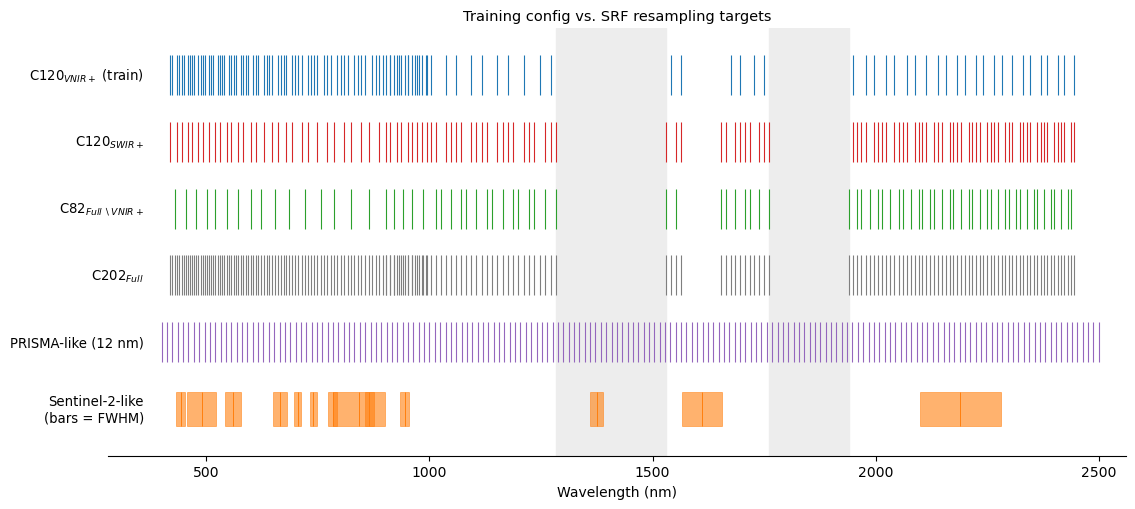

In [6]:
import numpy as np, matplotlib.pyplot as plt
# exec(open('plot_standalone.py').read().split('rows = [')[0])  # lam, IDX_*, train/sw/c82/c202

prisma = np.arange(400, 2500+1e-6, 12.0)
S2 = [("B1",443,20),("B2",490,65),("B3",560,35),("B4",665,30),("B5",705,15),
      ("B6",740,15),("B7",783,20),("B8",842,115),("B8A",865,20),("B9",945,20),
      ("B10",1375,30),("B11",1610,90),("B12",2190,180)]

fig, ax = plt.subplots(figsize=(11.5, 5.2))
for lo,hi in [(1283.29,1530.64),(1759.83,1939.44)]:
    ax.axvspan(lo,hi,color="0.93",zorder=0)

# NOW includes C120_SWIR+  (sw)
rug = [(r"C120$_{VNIR+}$ (train)", [lam[i] for i in sorted(train)], "#1f77b4"),
       (r"C120$_{SWIR+}$",          [lam[i] for i in sorted(sw)],   "#d62728"),
       (r"C82$_{Full\setminus VNIR+}$", [lam[i] for i in sorted(c82)], "#2ca02c"),
       (r"C202$_{Full}$",           [lam[i] for i in sorted(c202)], "#7f7f7f"),
       (r"PRISMA-like (12 nm)",     list(prisma),                   "#9467bd")]
total = len(rug) + 1

for k,(name,xs,c) in enumerate(rug):
    y = total-1-k
    ax.vlines(xs, y-0.30, y+0.30, color=c, lw=0.8)
    ax.text(360, y, name, ha="right", va="center", fontsize=9.5)

y=0
for name,cen,fw in S2:
    ax.barh(y, fw, left=cen-fw/2, height=0.5, color="#ff7f0e", alpha=0.6,
            edgecolor="#ff7f0e", lw=0.6)
    ax.vlines(cen, y-0.25, y+0.25, color="#ff7f0e", lw=0.7)
ax.text(360, y, "Sentinel-2-like\n(bars = FWHM)", ha="right", va="center", fontsize=9.5)

ax.set_xlim(280,2560); ax.set_ylim(-0.7, total-0.3); ax.set_yticks([])
ax.set_xlabel("Wavelength (nm)")
ax.set_title("Training config vs. SRF resampling targets", fontsize=10.5)
for s in ["top","right","left"]: ax.spines[s].set_visible(False)
plt.tight_layout()
plt.savefig("srf_config_full.png",dpi=200,bbox_inches="tight")
plt.savefig("srf_config_full.pdf",bbox_inches="tight")
print("rows:", [r[0] for r in rug] + ["Sentinel-2-like"])